
# 5f. Biodiversity, bioeconomic models & natural capital valuation

Fifth and final notebook of the Chapter 5 (Impact Investing) biodiversity
case study, covering bioeconomic models and natural-capital valuation.

Topics covered, in order:

1. Logistic growth with harvesting: the Gordon-Schaefer model, equilibrium
   and collapse dynamics, and harvest-policy comparisons (fixed quota,
   fixed proportion, fixed escapement)
2. Predator-prey (Lotka-Volterra) dynamics: the basic model, phase
   portraits, predator harvesting, prey- vs. ratio-dependent functional
   responses, and a 4-species competitive Lotka-Volterra system
3. Consumer functional-response types I-IV
4. A stylized whale-population recovery model
5. Real fisheries data: UK historical catch (with war/regulatory-period
   annotations), North Sea/Atlantic cod catch and stock over five
   centuries, world fisheries production and capture-vs-aquaculture mix,
   and global fish discards
6. Natural-capital asset valuation: the option value of delaying harvest
7. Global rhinoceros population by species (real data)
8. The Biodiversity Intactness Index (BII), 2001-2012 change by region
9. Marine-protected-area blended-finance economics and IPBES-style
   ecosystem-service value-range tables (illustrative/report-derived)
10. The mitigation hierarchy (no-net-loss) diagram

All ODE-based dynamics use `scipy.integrate.solve_ivp`. Sections 5 and 7-8
use real data via `pandas.read_excel` (UK/global fisheries data, rhino
population data, and the De Palma et al. Biodiversity Intactness Index
dataset); sections 1-4, 6, 9 and 10 reproduce the book's illustrative
theoretical figures and report-derived summary tables from hardcoded
parameter values — there is no underlying dataset to read for these.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

DATA_DIR = "../../data"

color_blue    = "#1f77b4"
color_red     = "#d62728"
color_green   = "#2ca02c"
color_violet  = "#9467bd"
color_teal    = "#17becf"
color_orange  = "#ff7f0e"
color_black   = "#000000"
colors_accent = [color_blue, color_orange, color_green, color_red,
                  color_violet, "#8c564b", color_teal]

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = False



## 1. Logistic growth with harvesting (Gordon-Schaefer model)

The classic bioeconomic fisheries model: population growth follows
logistic growth $\delta x(1-x/\kappa)$ reduced by a harvest term. The
maximum sustainable yield (MSY) is $\delta\kappa/4$, reached at
$x=\kappa/2$.


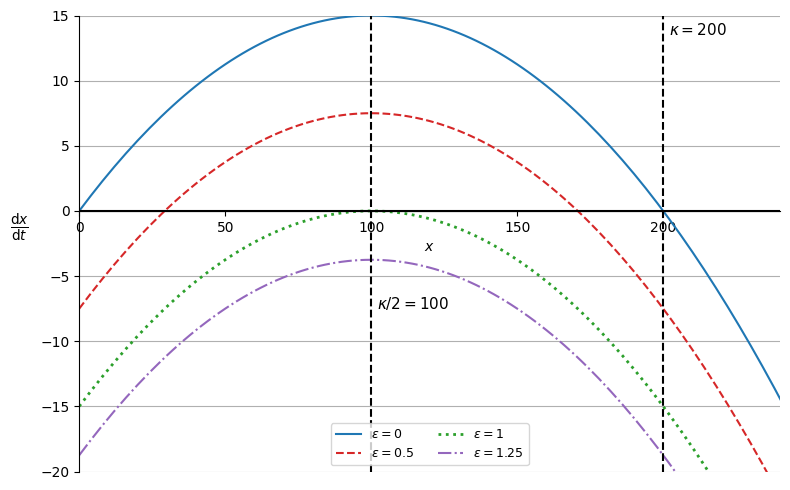

In [2]:

delta, kappa = 0.30, 200

epsilon = np.array([0, 0.50, 1.00, 1.25])
h = epsilon * delta * kappa / 4
x = np.arange(0, 1.50 * kappa + 1, 2)

fig, ax = plt.subplots(figsize=(8, 5))
styles = ["-", "--", ":", "-."]
lws = [1.5, 1.5, 2.0, 1.5]
for i, eps in enumerate(epsilon):
    dx = delta * x * (1 - x / kappa) - h[i]
    ax.plot(x, dx, styles[i], color=[color_blue, color_red, color_green, color_violet][i],
            lw=lws[i], label=fr"$\epsilon = {eps:g}$")
ax.axhline(0, color=color_black, lw=1.5)
ax.axvline(kappa, ls="--", color=color_black, lw=1.5)
ax.axvline(kappa / 2, ls="--", color=color_black, lw=1.5)
ax.text(kappa + 2, 13.5, r"$\kappa = 200$", fontsize=11)
ax.text(kappa / 2 + 2, -7.5, r"$\kappa/2 = 100$", fontsize=11)
ax.set_xlabel("$x$")
ax.set_ylabel(r"$\frac{\mathrm{d}x}{\mathrm{d}t}$", rotation=0, fontsize=14, labelpad=15)
ax.legend(ncol=2, fontsize=9, loc="lower center")
ax.grid(axis="y")
ax.spines["bottom"].set_position("zero")
ax.set_xlim(0, 240); ax.set_ylim(-20, 15)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 37b — Time trajectories for each harvest level

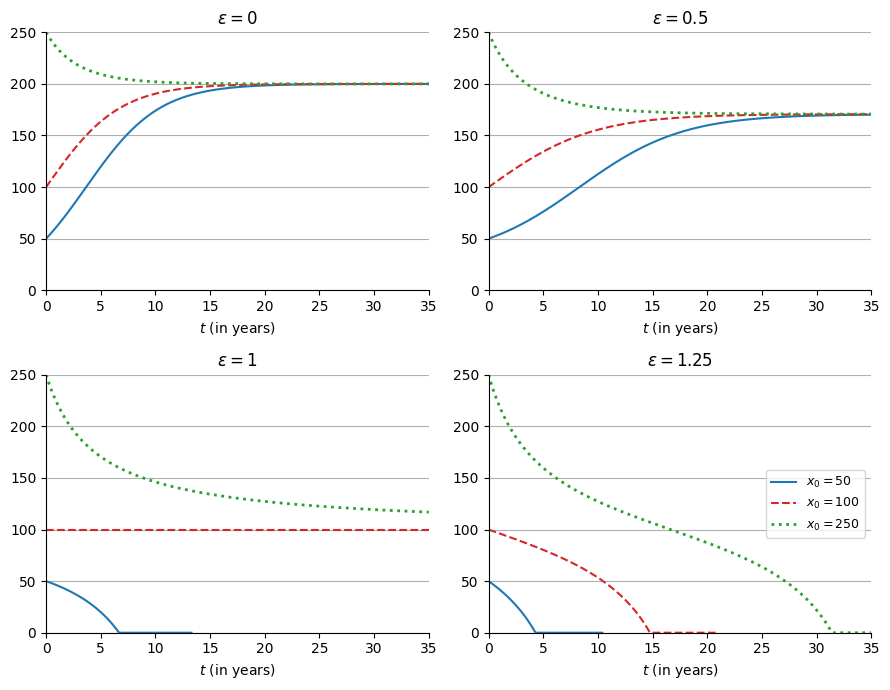

In [3]:

x0_list = [50, 100, 250]

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for j, (ax, eps) in enumerate(zip(axes.ravel(), epsilon)):
    hj = eps * delta * kappa / 4
    for x0, style, c in zip(x0_list, ["-", "--", ":"], [color_blue, color_red, color_green]):
        sol = solve_ivp(lambda t, x: delta * x * (1 - x / kappa) - hj, [0, 35], [x0],
                         t_eval=np.linspace(0, 35, 351), max_step=0.1)
        x_t = np.maximum(sol.y[0], 0)
        ax.plot(sol.t, x_t, style, color=c, lw=1.5 if style != ":" else 2.0,
                label=fr"$x_0 = {x0}$" if j == 3 else None)
    ax.set_title(fr"$\epsilon = {eps:g}$", fontsize=12)
    ax.set_xlabel("$t$ (in years)")
    ax.set_xlim(0, 35); ax.set_ylim(0, 250)
    ax.grid(axis="y")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[1, 1].legend(fontsize=9, loc="center right")
plt.tight_layout()
plt.show()


### 37c — Equilibrium biomass vs. harvest intensity

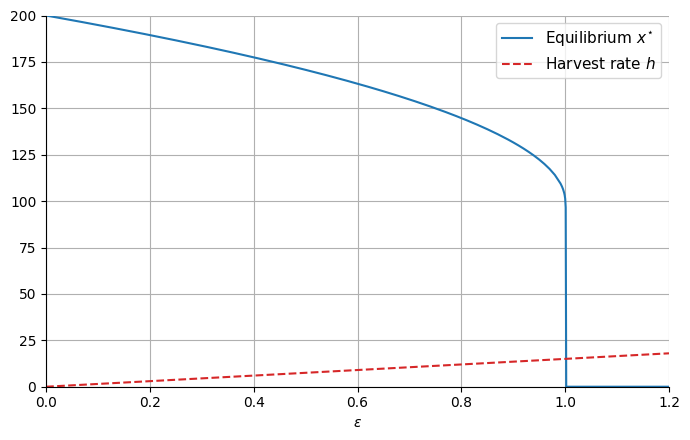

In [4]:

tspan = [0, 500]
epsilon_grid = np.concatenate([np.arange(0, 0.991, 0.01), np.arange(0.99, 1.011, 0.001),
                                np.arange(1.01, 1.201, 0.01)])
h_grid = epsilon_grid * delta * kappa / 4
x_star = np.empty_like(epsilon_grid)
for i, hi in enumerate(h_grid):
    sol = solve_ivp(lambda t, x: delta * x * (1 - x / kappa) - hi, tspan, [250], max_step=1.0)
    x_star[i] = max(sol.y[0, -1], 0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(epsilon_grid, x_star, "-", color=color_blue, lw=1.5, label=r"Equilibrium $x^{\star}$")
ax.plot(epsilon_grid, h_grid, "--", color=color_red, lw=1.5, label="Harvest rate $h$")
ax.set_xlabel(r"$\epsilon$")
ax.set_xlim(0, 1.20); ax.set_ylim(0, 200)
ax.grid(True)
ax.legend(fontsize=11, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



### 37d — Biomass path as effort approaches the collapse threshold

Effort rates $\eta = h/\kappa$ approaching $\delta/4 = 0.075$ (the point
past which sustained harvest is impossible for this $\delta,\kappa$).


In [5]:

delta2, kappa2 = 0.10, 100
x0 = kappa2
tspan_pts = [0, 10, 20, 30, 40]
eta = np.array([0.01, 0.02, 0.03, 0.04, 0.041, 0.042, 0.043, 0.044])
h2 = eta * kappa2

rows = []
for hj in h2:
    sol = solve_ivp(lambda t, x: delta2 * x * (1 - x / kappa2) - hj, [0, 40], [x0],
                     t_eval=tspan_pts, max_step=0.1)
    rows.append(np.maximum(sol.y[0], 0))

table_37d = pd.DataFrame(rows, index=[f"eta={e:.3f}" for e in eta], columns=tspan_pts).T
table_37d.round(2)


,eta=0.010,eta=0.020,eta=0.030,eta=0.040,eta=0.041,eta=0.042,eta=0.043,eta=0.044
0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
10,93.55,86.81,79.77,72.40,71.65,70.89,70.12,69.36
20,90.88,80.64,68.95,55.35,53.85,52.34,50.79,49.22
30,89.71,77.32,61.63,40.10,37.45,34.68,31.78,28.74
40,89.18,75.41,55.85,21.32,16.04,10.18,3.62,0.00



### 37e — Theta-logistic growth under four harvest policies

Generalizing to $\delta x(1-(x/\kappa)^\theta)$, compared under: a fixed
harvest quota, two fixed-proportion (effort-based) harvest rates, and a
fixed-escapement policy (harvest only above a minimum stock).


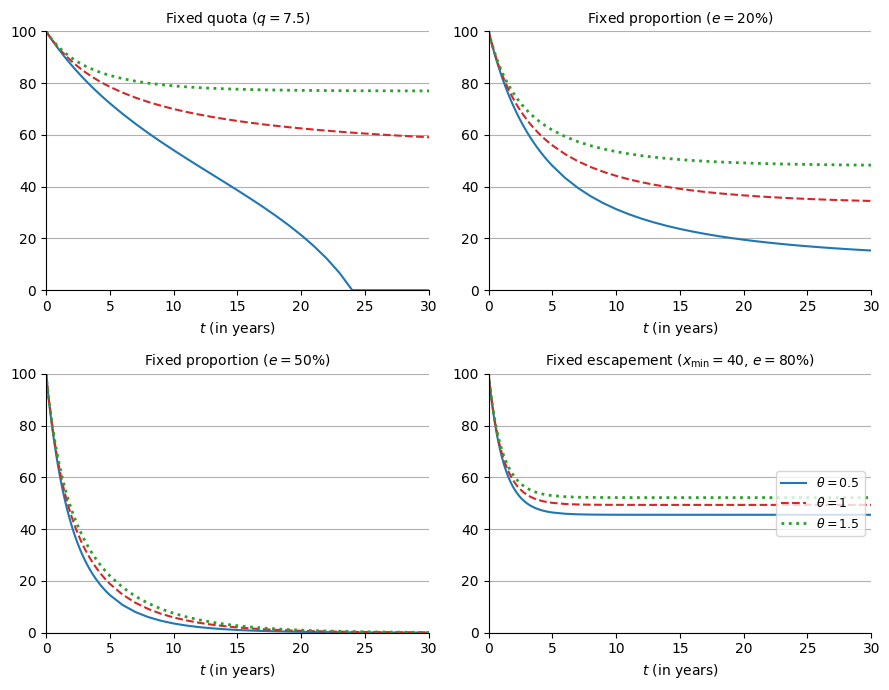

In [6]:

delta3, kappa3 = 0.30, 100
theta_vals = [0.5, 1.0, 1.5]
x0_3 = 100
q = delta3 / 4 * kappa3
e1, e2, e3 = 0.20, 0.50, 0.80
x_min = 40
t_eval = np.concatenate([np.arange(0, 5.01, 0.1), np.arange(6, 51, 1)])

policies = [
    ("Fixed quota ($q = 7.5$)",
     lambda x, th: delta3 * x * (1 - (x / kappa3) ** th) - q),
    (r"Fixed proportion ($e = 20\%$)",
     lambda x, th: (delta3 - e1) * x - delta3 * (x ** 2 / kappa3) * (x / kappa3) ** (th - 1)),
    (r"Fixed proportion ($e = 50\%$)",
     lambda x, th: delta3 * x * (1 - (x / kappa3) ** th) - e2 * x),
    (r"Fixed escapement ($x_{\min} = 40$, $e = 80\%$)",
     lambda x, th: delta3 * x * (1 - (x / kappa3) ** th) - e3 * np.maximum(0, x - x_min)),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, (title, rhs) in zip(axes.ravel(), policies):
    for th, style, c in zip(theta_vals, ["-", "--", ":"], [color_blue, color_red, color_green]):
        sol = solve_ivp(lambda t, x, th=th, rhs=rhs: [np.real(rhs(max(x[0], 0), th))],
                         [0, 50], [x0_3], t_eval=t_eval, max_step=0.1)
        x_t = np.maximum(np.real(sol.y[0]), 0)
        ax.plot(sol.t, x_t, style, color=c, lw=2.0 if style == ":" else 1.5,
                label=fr"$\theta = {th:g}$" if title.startswith("Fixed escapement") else None)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$t$ (in years)")
    ax.set_xlim(0, 30); ax.set_ylim(0, 100)
    ax.grid(axis="y")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[1, 1].legend(fontsize=9, loc="center right")
plt.tight_layout()
plt.show()



## 2. Predator-prey (Lotka-Volterra) dynamics

The classic Lotka-Volterra system $\dot{x}=ax-bxy$, $\dot{y}=cxy-dy$
(prey $x$, predator $y$), plus several extensions.


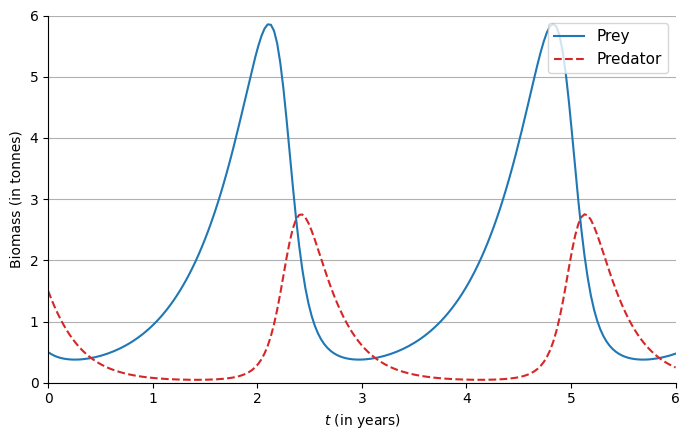

In [7]:

a, b, c, d = 2, 3, 2, 4

def lv(t, z):
    x, y = z
    return [a * x - b * x * y, c * x * y - d * y]

sol = solve_ivp(lv, [0, 6], [0.5, 1.5], t_eval=np.linspace(0, 6, 201), max_step=0.01)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sol.t, sol.y[0], "-", color=color_blue, lw=1.5, label="Prey")
ax.plot(sol.t, sol.y[1], "--", color=color_red, lw=1.5, label="Predator")
ax.set_xlabel("$t$ (in years)")
ax.set_ylabel("Biomass (in tonnes)")
ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.grid(axis="y")
ax.legend(fontsize=11, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 37g — Phase-plane direction field

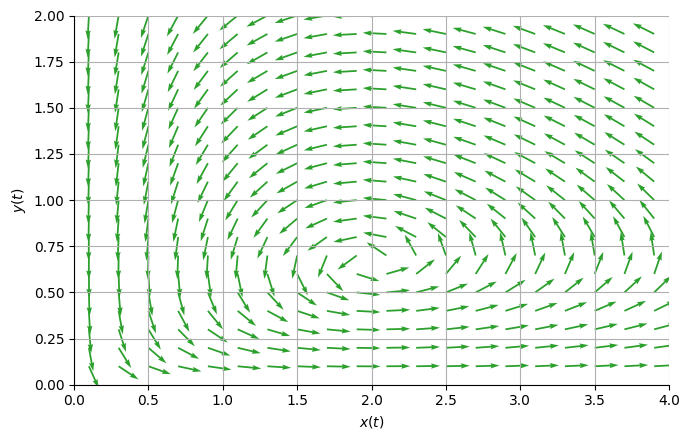

In [8]:

dx_grid = np.arange(0.1, 4.01, 0.2)
dy_grid = np.arange(0.1, 2.01, 0.1)
X, Y = np.meshgrid(dx_grid, dy_grid)
DU = a * X - b * X * Y
DV = c * X * Y - d * Y
norm = np.sqrt(DU ** 2 + DV ** 2)
U, V = DU / norm, DV / norm

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.quiver(X, Y, U, V, color=color_green, scale=25, width=0.003)
ax.set_xlabel("$x(t)$")
ax.set_ylabel("$y(t)$")
ax.set_xlim(0, 4); ax.set_ylim(0, 2)
ax.grid(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 37h — Closed orbits around the coexistence equilibrium

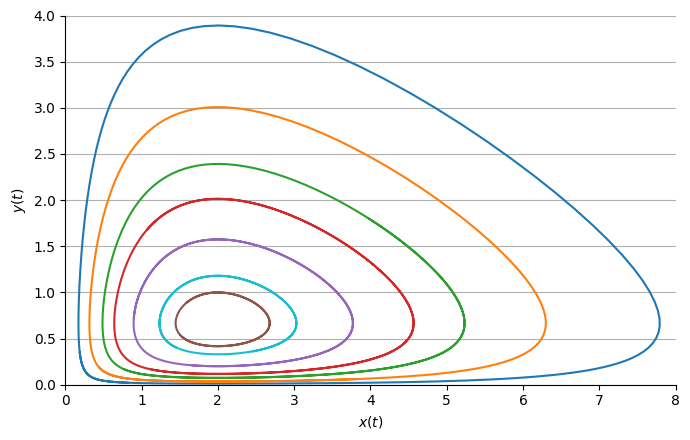

In [9]:

x0s = [0.22, 0.35, 0.5, 0.65, 0.9, 2.0, 1.30]
y0s = [0.22, 0.35, 0.5, 0.55, 0.6, 1.0, 0.50]

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (x0, y0) in enumerate(zip(x0s, y0s)):
    sol1 = solve_ivp(lv, [0, 3], [x0, y0], max_step=0.01)
    z0 = sol1.y[:, -1]
    sol2 = solve_ivp(lv, [0, 4], z0, t_eval=np.linspace(0, 4, 401), max_step=0.01)
    ax.plot(sol2.y[0], sol2.y[1], "-", color=colors_accent[i % len(colors_accent)], lw=1.5)
ax.set_xlabel("$x(t)$")
ax.set_ylabel("$y(t)$")
ax.set_xlim(0, 8); ax.set_ylim(0, 4)
ax.grid(axis="y")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 37i — Predator harvesting above a minimum stock

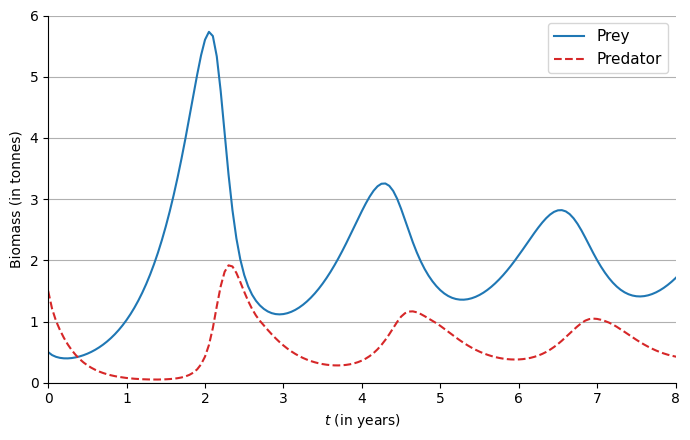

In [10]:

e_y, y_min = 5.0, 1.0

def lv_harvest(t, z):
    x, y = z
    return [a * x - b * x * y, c * x * y - d * y - e_y * max(0, y - y_min)]

sol = solve_ivp(lv_harvest, [0, 10], [0.5, 1.5], t_eval=np.linspace(0, 10, 201), max_step=0.01)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sol.t, sol.y[0], "-", color=color_blue, lw=1.5, label="Prey")
ax.plot(sol.t, sol.y[1], "--", color=color_red, lw=1.5, label="Predator")
ax.set_xlabel("$t$ (in years)")
ax.set_ylabel("Biomass (in tonnes)")
ax.set_xlim(0, 8); ax.set_ylim(0, 6)
ax.grid(axis="y")
ax.legend(fontsize=11, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 37j — Consumer functional-response types I-IV

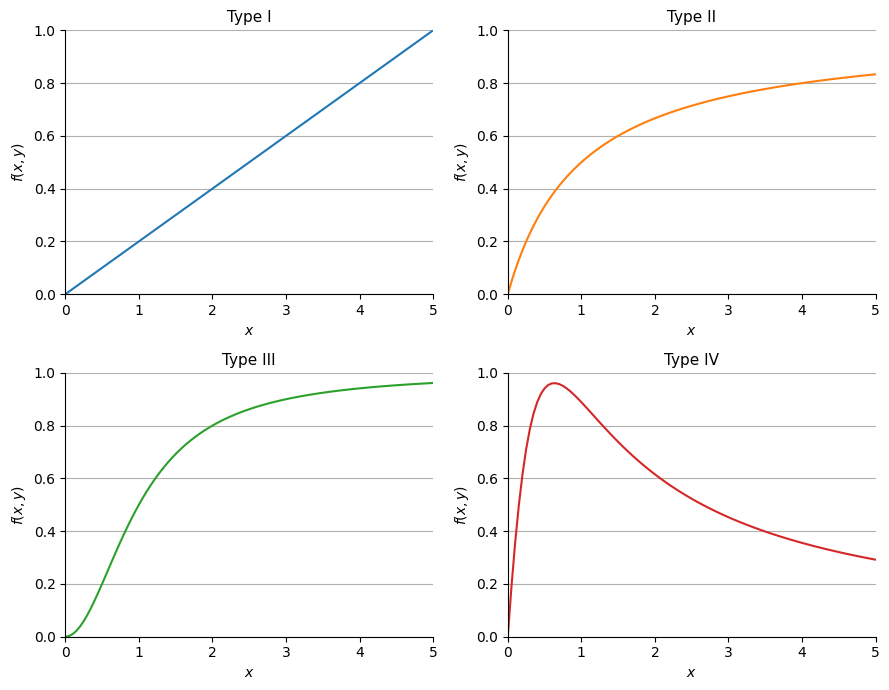

In [11]:

x_fr = np.arange(0, 5.01, 0.05)
y1 = 0.2 * x_fr
y2 = 1 * x_fr / (1 + x_fr)
y3 = 1 * x_fr ** 2 / (1 + x_fr ** 2)
alpha4, beta4, gamma4 = 4.0, 1, 2.5
y4 = alpha4 * x_fr / (beta4 + x_fr + gamma4 * x_fr ** 2)

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, y, title, c in zip(axes.ravel(), [y1, y2, y3, y4],
                            ["Type I", "Type II", "Type III", "Type IV"], colors_accent):
    ax.plot(x_fr, y, "-", color=c, lw=1.5)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x,y)$")
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 5); ax.set_ylim(0, 1)
    ax.grid(axis="y")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 37k — Prey-dependent vs. ratio-dependent predator-prey models

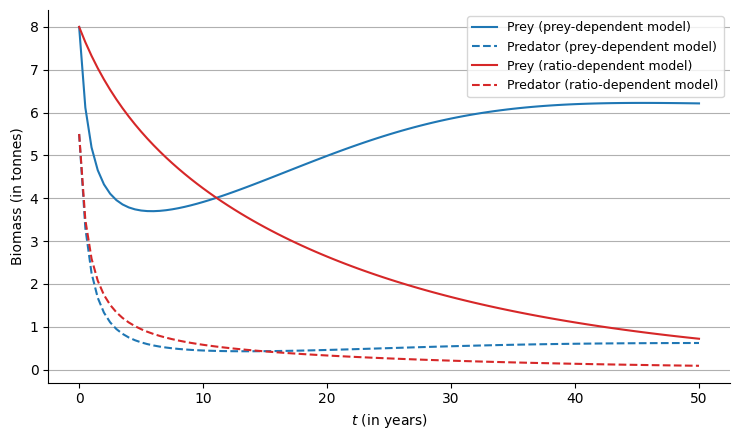

In [12]:

delta_k, kappa_k, alpha_k, sigma_k, gamma_k = 0.10, 100, 4, 0.20, 0.10

def prey_dependent(t, z, beta):
    x, y = z
    x = max(x, 1e-9)
    return [delta_k * x * (1 - x / kappa_k) - alpha_k * x * y / (beta + x),
            sigma_k * y * (1 - y / (gamma_k * x))]

def ratio_dependent(t, z, beta):
    x, y = z
    x, y = max(x, 1e-9), max(y, 1e-9)
    return [delta_k * x * (1 - x / kappa_k) - alpha_k * x * y / (beta * y + x),
            sigma_k * y * (1 - y / (gamma_k * x))]

t_eval_k = np.arange(0, 50.01, 0.5)
sol_a = solve_ivp(prey_dependent, [0, 50], [8, 5.5], args=(20,), t_eval=t_eval_k, max_step=0.1)
sol_b = solve_ivp(ratio_dependent, [0, 50], [8, 5.5], args=(20,), t_eval=t_eval_k, max_step=0.1)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sol_a.t, sol_a.y[0], "-", color=color_blue, lw=1.5, label="Prey (prey-dependent model)")
ax.plot(sol_a.t, sol_a.y[1], "--", color=color_blue, lw=1.5, label="Predator (prey-dependent model)")
ax.plot(sol_b.t, sol_b.y[0], "-", color=color_red, lw=1.5, label="Prey (ratio-dependent model)")
ax.plot(sol_b.t, sol_b.y[1], "--", color=color_red, lw=1.5, label="Predator (ratio-dependent model)")
ax.set_xlabel("$t$ (in years)")
ax.set_ylabel("Biomass (in tonnes)")
ax.grid(axis="y")
ax.legend(fontsize=9, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 37l/37m — Four-species competitive Lotka-Volterra system

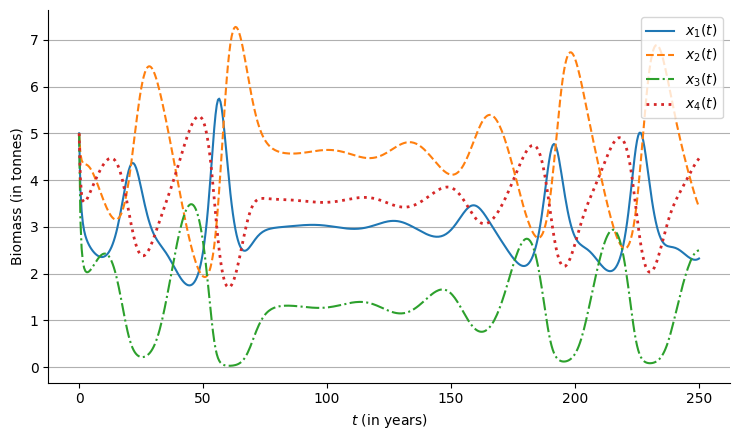

In [13]:

c_scale = 10
delta_v = np.array([1.00, 0.72, 1.53, 1.27])
kappa_v = c_scale * np.ones(4)
Omega = np.array([
    [1.00, 1.09, 1.52, 0.00],
    [0.00, 1.00, 0.44, 1.36],
    [2.33, 0.00, 1.00, 0.47],
    [1.21, 0.51, 0.35, 1.00],
])

def competition(t, x):
    x = np.asarray(x)
    return delta_v * x * (1 - (Omega @ x) / kappa_v)

x0_37l = c_scale * np.full(4, 0.5)
sol = solve_ivp(competition, [0, 250], x0_37l, t_eval=np.arange(0, 250.5, 0.5), max_step=0.1)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
styles = ["-", "--", "-.", ":"]
for i in range(4):
    ax.plot(sol.t, sol.y[i], styles[i], color=colors_accent[i], lw=2.0 if styles[i] == ":" else 1.5,
            label=f"$x_{i+1}(t)$")
ax.set_xlabel("$t$ (in years)")
ax.set_ylabel("Biomass (in tonnes)")
ax.grid(axis="y")
ax.legend(fontsize=10, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


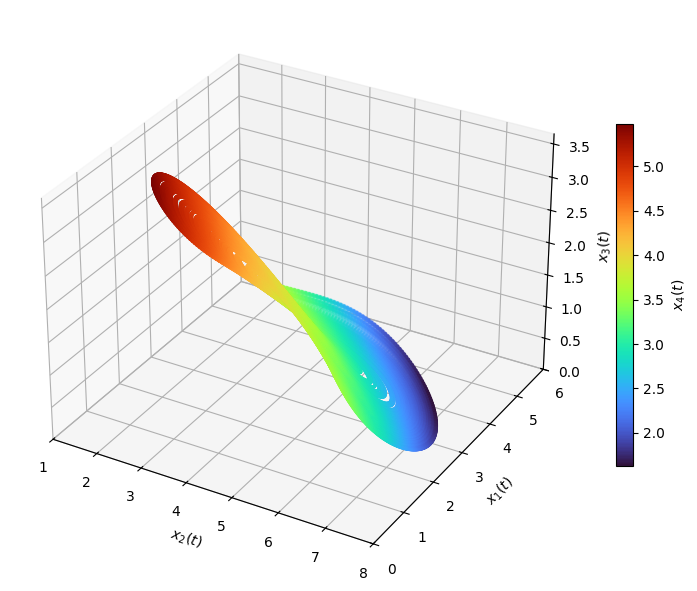

In [14]:

x0_37m = c_scale * np.full(4, 0.2)
sol1 = solve_ivp(competition, [0, 1000], x0_37m, max_step=0.5)
sol2 = solve_ivp(competition, [0, 5000], sol1.y[:, -1], t_eval=np.arange(0, 5000.1, 0.1), max_step=0.5)

fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(111, projection="3d")
sca = ax.scatter(sol2.y[1], sol2.y[0], sol2.y[2], c=sol2.y[3], cmap="turbo", s=2)
fig.colorbar(sca, ax=ax, shrink=0.6, label="$x_4(t)$")
ax.set_xlabel("$x_2(t)$")
ax.set_ylabel("$x_1(t)$")
ax.set_zlabel("$x_3(t)$")
ax.invert_yaxis()
ax.set_xlim(c_scale * 0.1, c_scale * 0.8)
ax.set_ylim(c_scale * 0.0, c_scale * 0.6)
ax.set_zlim(c_scale * 0.0, c_scale * 0.365)
plt.tight_layout()
plt.show()



## 3. A stylized whale-population recovery model

A bounded exponential-recovery model
$N_t = N_0[(1-\varphi)e^{-rt}+\varphi]$ for four whale populations/regions,
with illustrative recovery-rate ($r$) and floor-population-share
($\varphi$) parameters — no underlying dataset (hardcoded here).


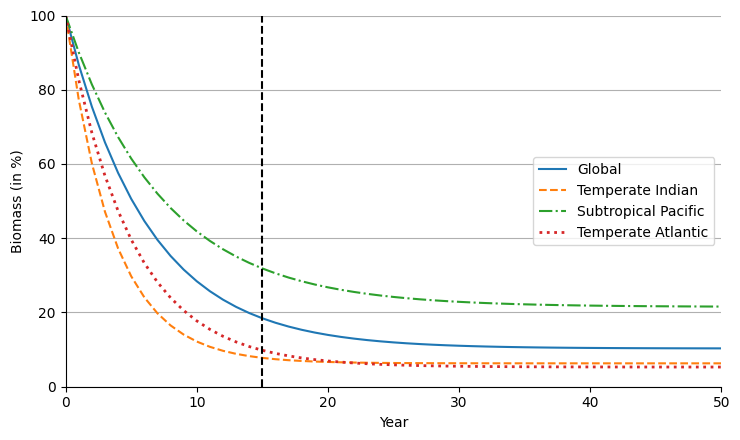

In [15]:

t = np.arange(0, 50.5, 1)
r = np.array([0.160, 0.277, 0.135, 0.203])
varphi = np.array([0.103, 0.063, 0.215, 0.053])
N0 = 100
Nt = N0 * ((1 - varphi) * np.exp(-np.outer(t, r)) + varphi)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = ["Global", "Temperate Indian", "Subtropical Pacific", "Temperate Atlantic"]
for i, (style, c) in enumerate(zip(["-", "--", "-.", ":"], colors_accent)):
    ax.plot(t, Nt[:, i], style, color=c, lw=2.0 if style == ":" else 1.5, label=labels[i])
ax.axvline(15, ls="--", color=color_black, lw=1.5)
ax.set_xlabel("Year")
ax.set_ylabel("Biomass (in %)")
ax.set_xlim(0, 50); ax.set_ylim(0, 100)
ax.grid(axis="y")
ax.legend(fontsize=10, loc="center right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## 4. Real fisheries data

UK historical catch, North Sea/Atlantic cod catch and stock over five
centuries, world fisheries production, and global fish discards — all
from real data (`data/chap5_fisheries_*.xlsx`, Our World in Data / RAM
Legacy stock assessment / World Bank sources).


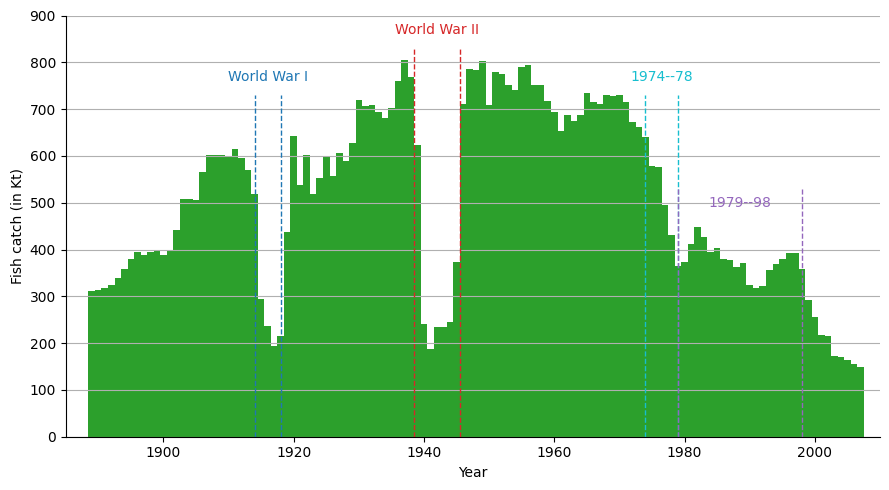

In [16]:

uk = pd.read_excel(f"{DATA_DIR}/chap5_fisheries_catch_uk.xlsx")
uk.columns = ["Entity", "Code", "Year", "FishCatch"]
uk_series = uk[uk["Entity"] == "United Kingdom"].sort_values("Year")
t_uk, y_uk = uk_series["Year"].values, uk_series["FishCatch"].values / 1000

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(t_uk, y_uk, color=color_green, width=1.0)

periods = [
    (1914, 1918, 730, "World War I", color_blue),
    (1938.5, 1945.5, 830, "World War II", color_red),
    (1974, 1979, 730, "1974--78", color_teal),
    (1979, 1998, 530, "1979--98", color_violet),
]
for a, b, y, label, c in periods:
    ax.plot([a, a], [0, y], "--", color=c, lw=1.0)
    ax.plot([b, b], [0, y], "--", color=c, lw=1.0)
    ax.text((a + b) / 2, y + (30 if label != "1979--98" else -40), label, color=c,
            ha="center", fontsize=10)

ax.set_xlabel("Year")
ax.set_ylabel("Fish catch (in Kt)")
ax.set_xlim(1885, 2010)
ax.set_ylim(0, 900)
ax.grid(axis="y")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


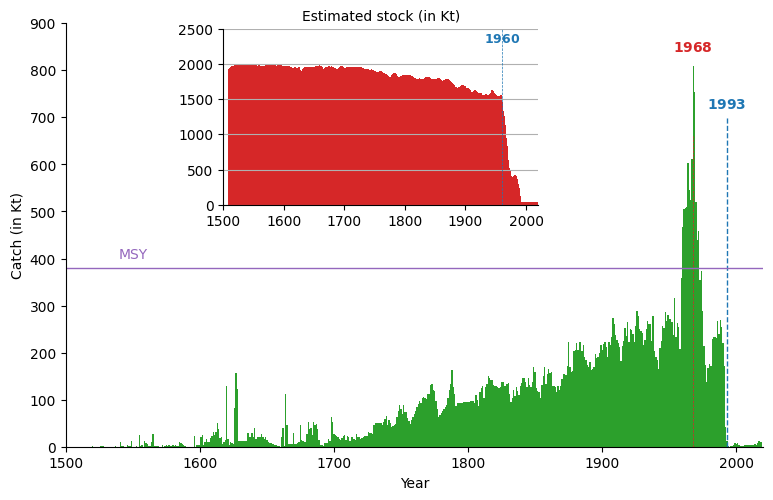

In [17]:

cod = pd.read_excel(f"{DATA_DIR}/chap5_fisheries_cod_catch.xlsx")
t_cod, y_cod, z_cod = cod["yr"].values, cod["ct"].values / 1000, cod["bt"].values / 1e3
t_max = t_cod[np.argmax(y_cod)]
y_max = y_cod.max()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(t_cod, y_cod, color=color_green, width=1.0)
ax.plot([t_max, t_max], [0, y_max - 150], "--", color=color_red, lw=0.5)
ax.text(t_max, y_max + 30, r"$\mathbf{1968}$", color=color_red, ha="center")
ax.plot([1993, 1993], [0, 700], "--", color=color_blue, lw=1.0)
ax.text(1993, 720, r"$\mathbf{1993}$", color=color_blue, ha="center")
ax.plot([1500, 2020], [380, 380], "-", color=color_violet, lw=1.0)
ax.text(1550, 400, "MSY", color=color_violet, ha="center")
ax.set_xlabel("Year")
ax.set_ylabel("Catch (in Kt)")
ax.set_xlim(1500, 2020); ax.set_ylim(0, 900)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax2 = fig.add_axes([0.30, 0.55, 0.35, 0.32])
ax2.bar(t_cod, z_cod, color=color_red, width=1.0)
ax2.axvline(1960, ls="--", color=color_blue, lw=0.5)
ax2.text(1960, 2300, r"$\mathbf{1960}$", color=color_blue, ha="center", fontsize=9)
ax2.set_title("Estimated stock (in Kt)", fontsize=10)
ax2.set_xlim(1500, 2020); ax2.set_ylim(0, 2500)
ax2.grid(axis="y")
for spine in ("top", "right"):
    ax2.spines[spine].set_visible(False)
plt.show()


Total growth ratio 1960-2022: 6.36x, annualized 2.98%


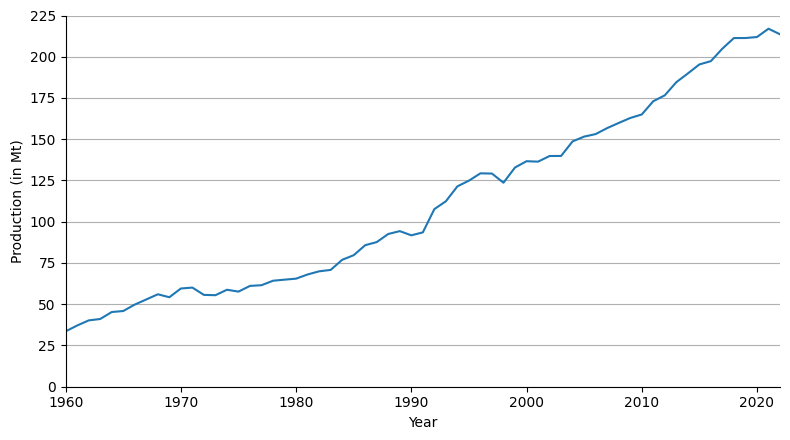

In [18]:

world_prod = pd.read_excel(f"{DATA_DIR}/chap5_fisheries_world_production.xlsx")
wld = world_prod[world_prod["Country Code"] == "WLD"]
year_cols = [c for c in world_prod.columns if c.startswith("YR")]
t_wp = np.array([int(c[2:]) for c in year_cols])
data_wld = wld[year_cols].values / 1e6  # rows: capture, aquaculture, total
y_total = data_wld[2]

growth_ratio = y_total[-1] / y_total[0]
annual_rate = 100 * (growth_ratio ** (1 / (2022 - 1960 + 1)) - 1)
print(f"Total growth ratio 1960-2022: {growth_ratio:.2f}x, annualized {annual_rate:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_wp, y_total, "-", color=color_blue, lw=1.5)
ax.set_xlabel("Year")
ax.set_ylabel("Production (in Mt)")
ax.set_xlim(1960, 2022); ax.set_ylim(0, 225)
ax.grid(axis="y")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 39b/39c — Top capture/aquaculture/total producers, and where do France/Japan/Canada/Spain/Germany rank?

In [19]:

year_snap = ["YR1960", "YR1980", "YR2000", "YR2010", "YR2020", "YR2022"]
series_labels = {"ER.FSH.CAPT.MT": "Capture fisheries", "ER.FSH.AQUA.MT": "Aquaculture",
                  "ER.FSH.PROD.MT": "Total fisheries"}

for series_code, label in series_labels.items():
    sub = world_prod[world_prod["Series Code"] == series_code]
    data = sub[year_snap].values / 1e6
    country = sub["Country Name"].values
    order = np.argsort(-np.nan_to_num(data[:, 0]))
    top15 = order[:15]
    d15 = data[top15].copy()
    with np.errstate(divide="ignore", invalid="ignore"):
        d15[:, 1:] = 100 * d15[:, 1:] / d15[:, [0]]
    print(f"--- Top 15, {label} (1960 level in Mt; later cols = % of 1960) ---")
    print(pd.DataFrame(d15, index=country[top15], columns=year_snap).round(1).to_string())
    print()


--- Top 15, Capture fisheries (1960 level in Mt; later cols = % of 1960) ---
                YR1960  YR1980  YR2000  YR2010  YR2020  YR2022
World             31.6   183.9   297.8   277.6   285.8   278.4
Japan              5.9   169.8    87.6    70.7    55.1    50.1
Peru               3.5    77.3   304.3   122.9   162.1   153.3
United States      2.7   136.4   176.4   162.0   157.3   157.0
China              2.2   142.1   669.2   679.6   607.0   595.0
Norway             1.4   182.3   208.6   204.8   189.4   188.5
India              1.1   186.3   333.7   422.4   417.2   496.1
United Kingdom     1.0    87.9    74.3    60.3    61.7     NaN
Canada             0.9   148.0   111.3   105.1    82.5    75.9
Spain              0.9   129.0   117.2   107.0    88.0    89.2
South Africa       0.9    98.5    75.6    72.9    68.7    53.9
Germany            0.8    68.2    26.6    31.7    27.6    23.4
Indonesia          0.7   242.7   610.6   791.5  1026.2  1086.3
France             0.7   100.1   106.6   

In [20]:

selected_country = ["Japan", "Canada", "Spain", "Germany", "France"]
sub = world_prod[world_prod["Series Code"] == "ER.FSH.PROD.MT"]
data = sub[year_snap].values / 1e6
country = sub["Country Name"].values
order = np.argsort(-np.nan_to_num(data[:, 0]))
data_sorted = data[order]
country_sorted = country[order]
rank = np.arange(1, len(country_sorted) + 1)

data_sorted_pct = data_sorted.copy()
with np.errstate(divide="ignore", invalid="ignore"):
    data_sorted_pct[:, 1:] = 100 * data_sorted_pct[:, 1:] / data_sorted_pct[:, [0]]

idx = [np.where(country_sorted == c)[0][0] for c in selected_country]
pd.DataFrame(data_sorted_pct[idx], index=[f"{c} (rank {rank[i]})" for c, i in zip(selected_country, idx)],
             columns=year_snap).round(2)


,YR1960,YR1980,YR2000,YR2010,YR2020,YR2022
Japan (rank 2),6.23,178.84,104.01,85.66,68.44,62.73
Canada (rank 9),0.93,147.89,124.63,122.24,100.44,93.51
Spain (rank 10),0.91,150.61,150.46,134.39,117.68,118.80
Germany (rank 12),0.79,71.40,34.26,36.02,31.01,26.18
France (rank 13),0.76,112.65,126.04,85.97,87.78,96.42


Capture share of total, 1960: 93.91%   Aquaculture share of total, 2022: 59.06%


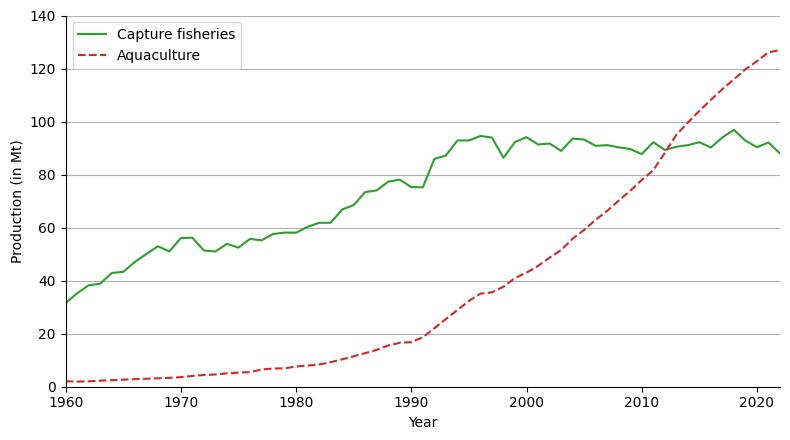

In [21]:

y1, y2 = data_wld[0], data_wld[1]  # capture, aquaculture
ratio_1960 = 100 * y1[0] / (y1[0] + y2[0])
ratio_2022 = 100 * y2[-1] / (y1[-1] + y2[-1])
print(f"Capture share of total, 1960: {ratio_1960:.2f}%   Aquaculture share of total, 2022: {ratio_2022:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_wp, y1, "-", color=color_green, lw=1.5, label="Capture fisheries")
ax.plot(t_wp, y2, "--", color=color_red, lw=1.5, label="Aquaculture")
ax.set_xlabel("Year")
ax.set_ylabel("Production (in Mt)")
ax.set_xlim(1960, 2022); ax.set_ylim(0, 140)
ax.grid(axis="y")
ax.legend(fontsize=10, loc="upper left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 40 — Global fish discards

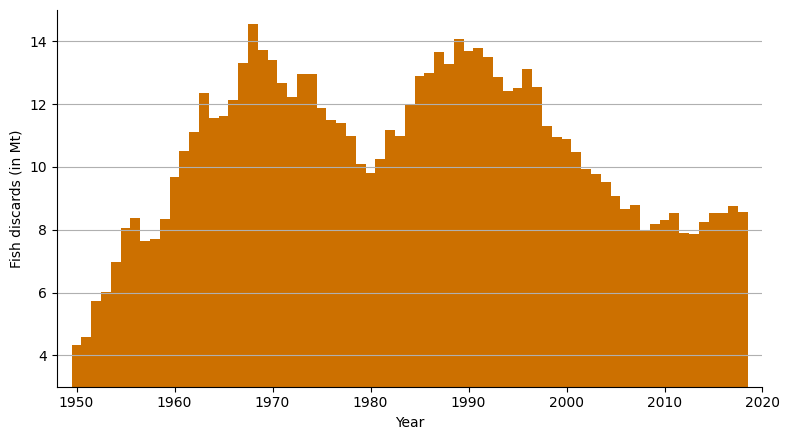

In [22]:

discards = pd.read_excel(f"{DATA_DIR}/chap5_fisheries_discards.xlsx")
discards.columns = ["Entity", "Code", "Year", "Discards"]
t_d, y_d = discards["Year"].values, discards["Discards"].values / 1e6

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(t_d, y_d, color="#cc7000", width=1.0)
ax.set_xlabel("Year")
ax.set_ylabel("Fish discards (in Mt)")
ax.set_xlim(1948, 2020); ax.set_ylim(3, 15)
ax.grid(axis="y")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## 5. The option value of delaying natural-capital harvest

An illustrative asset-valuation figure: a natural-capital asset's value
$W(t)=p_t v_t$ grows at price/volume growth rates until a harvest date
$t_0$, after which harvesting locks in a fixed value that then only
grows at a discount rate $r$ — showing the opportunity gain/cost of
harvesting early ($\tau=20$) vs. waiting ($\tau=50$). Purely
illustrative parameters, no underlying dataset.


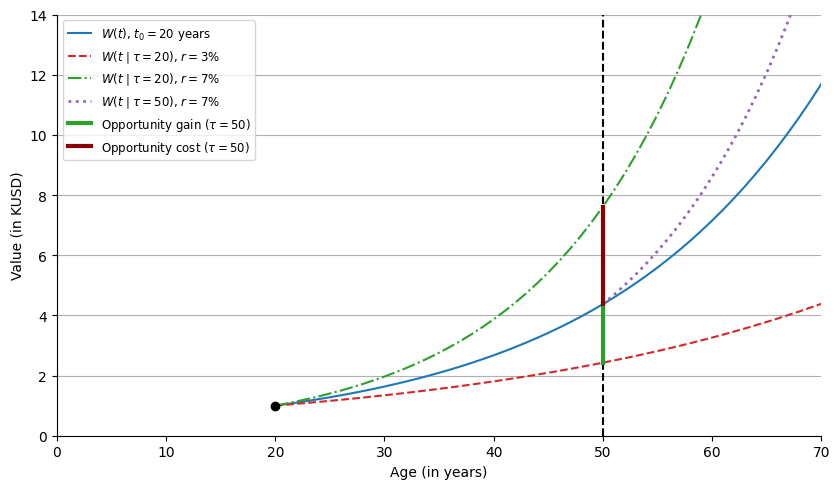

In [23]:

t = np.arange(0, 81, 1.0)
t0, p0, v0 = 20, 0.500, 2
delta_p, delta_v = 0.01, 0.04
W0 = p0 * v0

W1 = p0 * v0 * (1 + delta_p) ** (t - t0) * (1 + delta_v) ** (t - t0)
W1 = np.where(t < t0, np.nan, W1)

def harvest_at(tau, r_vals):
    p_tau = p0 * (1 + delta_p) ** (tau - t0)
    v_tau = v0 * (1 + delta_v) ** (tau - t0)
    out = np.array([p_tau * v_tau * (1 + r) ** (t - tau) for r in np.atleast_1d(r_vals)]).T
    out[t < tau] = np.nan
    return out

W2 = harvest_at(20, [0.03, 0.07])
W3 = harvest_at(50, [0.07])

indx50 = np.where(t == 50)[0][0]
tau = 50

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(t, W1, "-", color=color_blue, lw=1.5, label=r"$W(t)$, $t_0=20$ years")
ax.plot(t, W2[:, 0], "--", color=color_red, lw=1.5, label=r"$W(t\mid\tau=20)$, $r=3\%$")
ax.plot(t, W2[:, 1], "-.", color=color_green, lw=1.5, label=r"$W(t\mid\tau=20)$, $r=7\%$")
ax.plot(t, W3[:, 0], ":", color=color_violet, lw=2.0, label=r"$W(t\mid\tau=50)$, $r=7\%$")
ax.axvline(tau, ls="--", color=color_black, lw=1.5)
ax.plot([tau, tau], [W2[indx50, 0], W1[indx50]], "-", color="#2ca02c", lw=3.0,
        label="Opportunity gain ($\\tau=50$)")
ax.plot([tau, tau], [W2[indx50, 1], W1[indx50]], "-", color="#8b0000", lw=3.0,
        label="Opportunity cost ($\\tau=50$)")
ax.plot(t0, W0, "o", color=color_black, markersize=6)
ax.set_xlabel("Age (in years)")
ax.set_ylabel("Value (in KUSD)")
ax.set_xlim(0, 70); ax.set_ylim(0, 14)
ax.grid(axis="y")
ax.legend(fontsize=8.5, loc="upper left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## 6. Global rhinoceros population, by species

Data: `chap5_rhinoceros_data.xlsx` (Our World in Data, six rhino
species/subspecies population series, interpolated onto a common annual
grid).


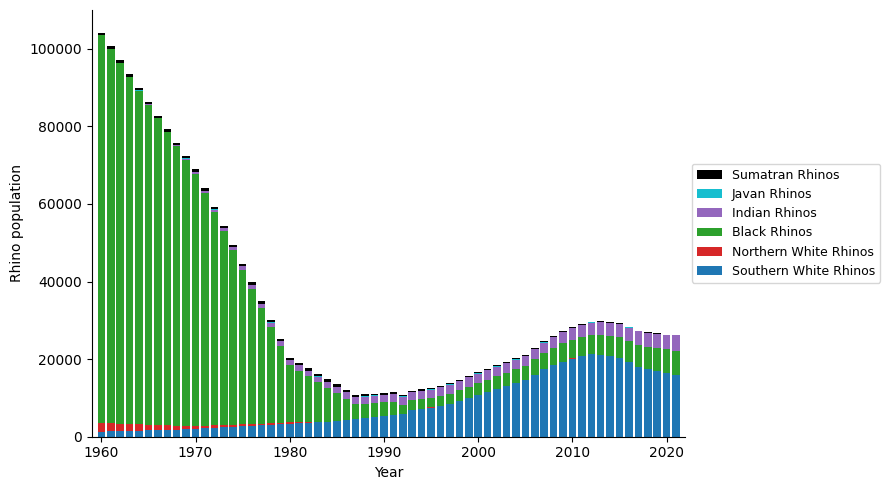

In [24]:

xl = pd.ExcelFile(f"{DATA_DIR}/chap5_rhinoceros_data.xlsx")
sheets = xl.sheet_names
t_rh = np.arange(1960, 2022)
rhinos = np.full((len(t_rh), len(sheets)), np.nan)
labels_rh = []
for i, s in enumerate(sheets):
    df = xl.parse(s)
    df.columns = ["Entity", "Code", "Year", "Population"]
    df = df.dropna(subset=["Year", "Population"]).sort_values("Year")
    labels_rh.append(df.columns[3])
    rhinos[:, i] = np.interp(t_rh, df["Year"], df["Population"])

labels_rh = [s.replace("-", " ").title() for s in sheets]
colors6 = [color_blue, color_red, color_green, color_violet, color_teal, color_black]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(t_rh))
for i in range(6):
    ax.bar(t_rh, rhinos[:, i], bottom=bottom, color=colors6[i], width=0.8, label=labels_rh[i])
    bottom += rhinos[:, i]
ax.set_xlabel("Year")
ax.set_ylabel("Rhino population")
ax.set_xlim(1959, 2022); ax.set_ylim(0, 1.1e5)
handles, labs = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labs[::-1], fontsize=9, loc="center left", bbox_to_anchor=(1.0, 0.5))
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## 7. The Biodiversity Intactness Index (BII), 2001 vs. 2012

Data: `chap5_biodiversity_depalma_bii.xlsx` (De Palma et al., mean
modeled BII by country/region and year), for three groups of countries:
South America, Central/West Africa, and Southeast/South Asia.


In [25]:

bii = pd.read_excel(f"{DATA_DIR}/chap5_biodiversity_depalma_bii.xlsx")

groups = {
    "South America": ["ARG", "BOL", "BRA", "CHL", "COL", "CUB", "PER", "PRY"],
    "Central/West Africa": ["CIV", "CMR", "COD", "COG", "GAB", "LBR", "SLE", "TGO"],
    "Southeast/South Asia": ["CHN", "KHM", "IDN", "IND", "LAO", "MYS", "THA", "VNM"],
}

rows = []
for group_name, isos in groups.items():
    for iso in isos:
        sub = bii[bii["Region"] == iso]
        bii_2001 = sub.loc[sub["Year"] == 2001, "Mean"].iloc[0]
        bii_2012 = sub.loc[sub["Year"] == 2012, "Mean"].iloc[0]
        rows.append({"Group": group_name, "ISO3": iso, "BII 2001 (%)": 100 * bii_2001,
                      "BII 2012 (%)": 100 * bii_2012,
                      "Change (%)": 100 * (bii_2012 / bii_2001 - 1)})

bii_table = pd.DataFrame(rows).set_index(["Group", "ISO3"])
bii_table.round(1)


BII 2001 (%)  BII 2012 (%)  Change (%)
Group                ISO3                                        
South America        ARG           48.3          46.4        -3.8
                     BOL           72.8          71.2        -2.2
                     BRA           82.7          80.7        -2.4
                     CHL           14.6          16.1        10.2
                     COL           81.2          80.0        -1.4
                     CUB           18.0          19.3         7.8
                     PER           88.2          87.5        -0.8
                     PRY           58.2          53.0        -8.9
Central/West Africa  CIV           57.0          41.9       -26.4
                     CMR           79.7          79.3        -0.5
                     COD           84.2          83.2        -1.2
                     COG           89.7          88.8        -1.1
                     GAB           87.9          87.3        -0.7
                     LBR           72.6          72.8         0.3
                     SLE           60.2          57.2        -4.9
                     TGO           58.7          57.7        -1.8
Southeast/South Asia CHN           38.6          36.4        -5.5
                     KHM           41.2          34.5       -16.2
                     IDN           75.8          70.4        -7.1
                     IND           13.3          13.0        -1.5
                     LAO           64.5          61.3        -4.9
                     MYS           79.6          70.5       -11.4
                     THA           31.0          29.7        -4.2
                     VNM           39.5          38.2        -3.4


## 8. Marine-protected-area blended finance & ecosystem-service value ranges

Stylized blended-finance return decomposition for a marine protected
area investment, and IPBES/TEEB-style ranges of ecosystem-service value
estimates from two meta-analyses (values per hectare; aggregate global
values in USD bn) — report-derived summary statistics hardcoded here, no
underlying dataset file.


In [26]:

data_43b = np.array([
    [1, 0.25, 0.90, 0.10, 0.29],
    [2, 0.50, 0.90, 0.25, 0.29],
    [3, 0.80, 0.80, 0.25, 0.29],
    [4, 0.75, 0.80, 0.20, 0.29],
])
w_s, pi_s, c_s, varphi_s, m_s = data_43b.T
T_return = pi_s * w_s * c_s
R_return = varphi_s * w_s * c_s * m_s
table_43b = pd.DataFrame({"Tranche return T": T_return, "Tranche return R": R_return},
                          index=[f"Tranche {int(i)}" for i in w_s])
table_43b.loc["Total"] = table_43b.sum()
table_43b.round(3)


,Tranche return T,Tranche return R
Tranche 1,0.225,0.026
Tranche 2,0.900,0.130
Tranche 3,1.920,0.174
Tranche 4,2.400,0.186
Total,5.445,0.516


In [27]:

def midpoint_table(data, col_labels):
    lower, upper = data[:, 0], data[:, 1]
    mid = 0.5 * (lower + upper)
    pct = 100 * mid / mid.sum()
    out = pd.DataFrame({col_labels[0]: lower, col_labels[1]: upper, "Midpoint": mid,
                        "Share of total (%)": pct})
    out.loc["Total"] = out.sum()
    return out.round(1)

data_44a = np.array([
    [74.6, 77.7], [26.9, 26.9], [6.3, 9.2], [5.5, 8.2],
    [4.0, 9.7], [3.8, 6.3], [1.7, 3.5], [0.8, 1.4],
])
print("Ecosystem-service value estimates, per hectare (USD '000/ha/year):")
midpoint_table(data_44a, ["Low estimate", "High estimate"])


Ecosystem-service value estimates, per hectare (USD '000/ha/year):


,Low estimate,High estimate,Midpoint,Share of total (%)
0,74.6,77.7,76.2,57.1
1,26.9,26.9,26.9,20.2
2,6.3,9.2,7.8,5.8
3,5.5,8.2,6.8,5.1
4,4.0,9.7,6.8,5.1
5,3.8,6.3,5.0,3.8
6,1.7,3.5,2.6,2.0
7,0.8,1.4,1.1,0.8
Total,123.6,142.9,133.2,100.0


In [28]:

data_44b = np.array([
    [315, 420], [149, 192], [81, 81], [73, 73],
    [36, 84], [27, 37], [23, 47], [19, 32],
])
print("Ecosystem-service value estimates, global aggregate (USD bn/year):")
midpoint_table(data_44b, ["Low estimate", "High estimate"])


Ecosystem-service value estimates, global aggregate (USD bn/year):


,Low estimate,High estimate,Midpoint,Share of total (%)
0,315.0,420.0,367.5,43.5
1,149.0,192.0,170.5,20.2
2,81.0,81.0,81.0,9.6
3,73.0,73.0,73.0,8.6
4,36.0,84.0,60.0,7.1
5,27.0,37.0,32.0,3.8
6,23.0,47.0,35.0,4.1
7,19.0,32.0,25.5,3.0
Total,723.0,966.0,844.5,100.0



## 9. The mitigation hierarchy (no-net-loss)

A schematic of the biodiversity mitigation hierarchy — avoid, minimize,
restore, offset — showing how each stage of a "no net loss" strategy
progressively narrows the residual biodiversity impact of a raw project
footprint, down to net gain in the best case.


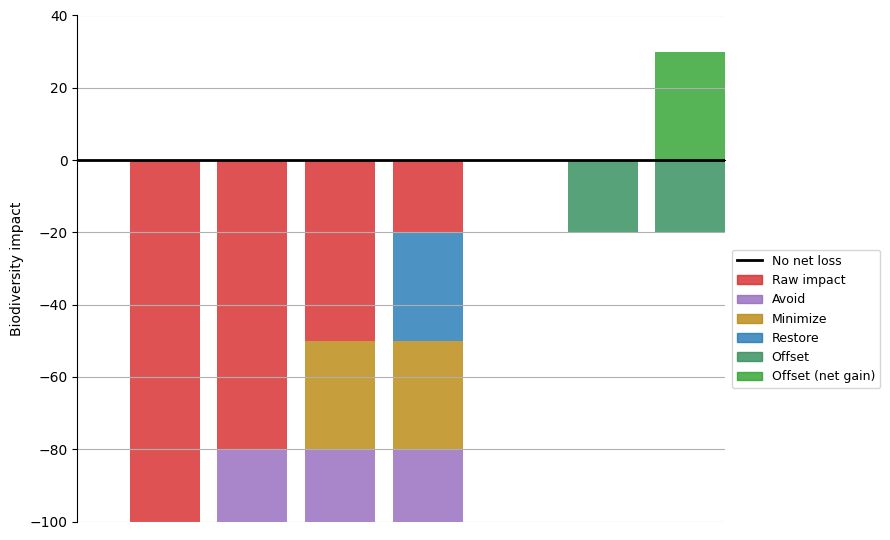

In [29]:

colors_45 = [color_red, color_violet, "#b8860b", color_blue, "#2e8b57", color_green]
alpha = 0.8

fig, ax = plt.subplots(figsize=(9, 5.5))

def patch(x_lo, x_hi, y_lo, y_hi, c):
    ax.fill_between([x_lo, x_hi], y_lo, y_hi, color=c, alpha=alpha, linewidth=0)

# Patch 1: raw impact only
patch(0.6, 1.4, -100, 0, colors_45[0])
# Patch 2: raw impact (avoid applied)
patch(1.6, 2.4, -80, 0, colors_45[0]); patch(1.6, 2.4, -100, -80, colors_45[1])
# Patch 3: + minimize
patch(2.6, 3.4, -50, 0, colors_45[0]); patch(2.6, 3.4, -100, -80, colors_45[1]); patch(2.6, 3.4, -80, -50, colors_45[2])
# Patch 4: + restore
patch(3.6, 4.4, -20, 0, colors_45[0]); patch(3.6, 4.4, -100, -80, colors_45[1])
patch(3.6, 4.4, -80, -50, colors_45[2]); patch(3.6, 4.4, -50, -20, colors_45[3])
# Patch 5: + offset (no net loss)
patch(5.6, 6.4, -20, 0, colors_45[4])
# Patch 6: + offset, net gain
patch(6.6, 7.4, -20, 0, colors_45[4]); patch(6.6, 7.4, 0, 30, colors_45[5])

line = ax.axhline(0, color=color_black, lw=2.0, label="No net loss")

from matplotlib.patches import Patch
legend_handles = [line,
                   Patch(color=colors_45[0], alpha=alpha, label="Raw impact"),
                   Patch(color=colors_45[1], alpha=alpha, label="Avoid"),
                   Patch(color=colors_45[2], alpha=alpha, label="Minimize"),
                   Patch(color=colors_45[3], alpha=alpha, label="Restore"),
                   Patch(color=colors_45[4], alpha=alpha, label="Offset"),
                   Patch(color=colors_45[5], alpha=alpha, label="Offset (net gain)")]
ax.legend(handles=legend_handles, fontsize=9, loc="center left", bbox_to_anchor=(1.0, 0.4))

ax.set_ylabel("Biodiversity impact")
ax.set_xlim(0, 7.4); ax.set_ylim(-100, 40)
ax.set_xticks([])
ax.grid(axis="y")
ax.spines["bottom"].set_position("zero")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## Summary

This notebook closes the Chapter 5 biodiversity case study with
bioeconomic and natural-capital-valuation theory: harvested logistic
growth (Gordon-Schaefer), predator-prey and multi-species competition
dynamics, functional-response types, a stylized whale-recovery model, real
UK/global fisheries and rhino-population data, the option value of
delayed harvest, the Biodiversity Intactness Index, and illustrative
natural-capital finance and mitigation-hierarchy figures.

No new packaging candidates: the ODE right-hand-side functions here are
all tied to this notebook's specific illustrative parameterizations
(Gordon-Schaefer harvest policies, Lotka-Volterra variants), not generic
primitives — a later chapter modeling a real fishery or ecosystem would
need its own calibrated system, not a reuse of these teaching examples.

This completes the five-notebook Chapter 5 biodiversity/impact-investing
case study (05a-05f).
